In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols
import sympy as sp

def Biseccion(f, a, b, tol):
    if f(a) * f(b) > 0:
        print("La función no cumple el teorema de Bolzano en el intervalo indicado")
        return None, None
    print("Buscando la solución...")
    i = 0
    while abs(b - a) > tol:
        p = (a + b) / 2
        i += 1
        if abs(f(p)) < tol:
            return p, i
        if f(a) * f(p) < 0:
            b = p
        else:
            a = p
    return (a + b) / 2, i

def PosicionFalsa(f, a, b, tol):
    if f(a) * f(b) > 0:
        print("La función no cumple el teorema de Bolzano en el intervalo indicado")
        return None, None
    i = 0
    p_anterior = a
    while True:
        p = b - f(b) * ((a - b) / (f(a) - f(b)))
        i += 1
        if abs(f(p)) < tol or abs(p - p_anterior) < tol:
            break
        if f(a) * f(p) < 0:
            b = p
        else:
            a = p
        p_anterior = p
    return p, i

def Newton(f, x, x0, tol, iteraciones=0):
    df = sp.diff(f, x)

    x1 = (x0 - f.evalf(subs={x: x0}) / df.evalf(subs={x: x0}))

    while abs(x1 - x0) > tol:
        print(f"Error {abs(x0 - x1)}")
        x0 = x1
        x1 = (x0 - f.evalf(subs={x: x0}) / df.evalf(subs={x: x0}))
        iteraciones += 1
        print(f"Iteración: {iteraciones}")
        print(f"X actual: {x0}")
        print(f"x{iteraciones}: {x1}")
        print("---------------------------")

    return x1, iteraciones, df

def secante(f, x0, x1, tol=1e-6, max_iter=100):
    i = 0
    while abs(f(x1)) > tol and i < max_iter:
        i += 1
        print(f"h{i}: {x1}")
        x_temp = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        x0, x1 = x1, x_temp
    return x1, i

In [38]:
r = 2
L = 5
V = 8.5
h0, h1 = 1.1, 1.3
tolerancia = 1e-6

funcion = lambda h: ((r**2) * np.arccos((r-h)/r) - (r - h * np.sqrt((2*r*h) - (h**2))))
raiz_aproximada, iteraciones = secante(funcion, h0, h1, tolerancia)
print(f"Raíz aproximada: {raiz_aproximada}, Iteraciones: {iteraciones}")

h1: 1.3
h2: 0.13471109194538444
h3: 0.2216384372758464
h4: 0.2046167962983682
h5: 0.20366547343353306
Raíz aproximada: 0.20367610362353672, Iteraciones: 5


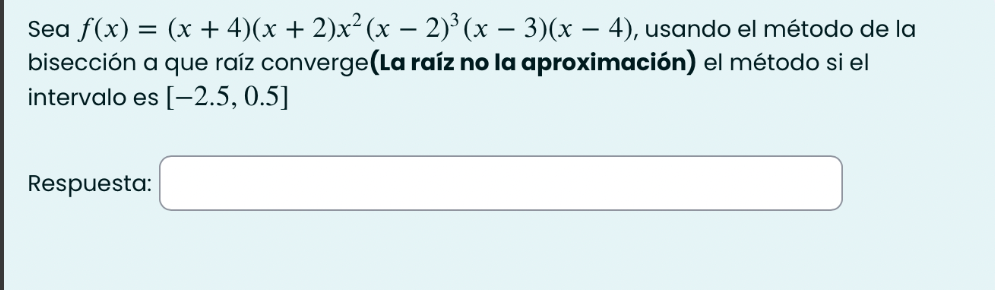

In [39]:
funcion = lambda x: (x + 4) * (x + 2) * (x**2) * ((x - 2)**3) * (x - 3) * (x - 4)
a, b = -2.5, 0.5
tolerancia = 1e-6
raiz_aproximada, iteraciones = Biseccion(funcion, a, b, tolerancia)
print(f"Raíz aproximada: {raiz_aproximada}, Iteraciones: {iteraciones}")
print("Como la raiz aproximada es {raiz_aproximada}, se puede concluir por estoy y por medio de la grafica que la raíz es -2.0")

Buscando la solución...
Raíz aproximada: -2.0000001192092896, Iteraciones: 22
Como la raiz aproximada es {raiz_aproximada}, se puede concluir por estoy y por medio de la grafica que la raíz es -2.0


![Grafica punto](https://i.gyazo.com/d45aa149103e093856d81643be604ea7.png "Grafica")

In [40]:
x = sp.symbols('x')
funcion = sp.ln(x**2 +1) - sp.exp((0.4)*x)*sp.cos(sp.pi*x)


print("ITEM 1")
#Se toma el X0 como -0.5 para que converga a la raíz negativa porque  en la gráfica se ve 
x0 = -0.5
tolerancia = 1e-6
raiz, iteraciones = Newton(funcion, x, x0, tolerancia)
print(f"El cero negativo aproximado: {raiz}")
print(f"Se encontró en {iteraciones} iteraciones.")
print("----------------------------")

print("ITEM 2")
#Se toma el X0 más cercano a la raíz positiva, en este caso 0.5 por la grafica
x_0 = 0.5
tolerancia = 1e-6
raiz, iteraciones = Newton(funcion, x, x_0, tolerancia)
print(f"Uno de los ceros positivos más pequeño: {raiz}")
print("--------------------------------")


ITEM 1
Error 0.0661731045477199
Iteración: 1
X actual: -0.433826895452280
x1: -0.434143058573108
---------------------------
Error 0.000316163120827384
Iteración: 2
X actual: -0.434143058573108
x2: -0.434143047285729
---------------------------


ValueError: too many values to unpack (expected 2)

![punto](https://i.gyazo.com/205180b3f854e7cda2c2468a909bd7f0.png)

In [ ]:

x = sp.symbols('x')
funcion = (x**4) - (93*(x**2) + 1350)
x0=-10
tolerancia = 1e-6
raiz, iteraciones, derivada = Newton(funcion, x, x0, tolerancia)


Error 0.303738317757009
Iteración: 1
X actual: -10.3037383177570
---------------------------
Error 0.0194795814314759
Iteración: 2
X actual: -10.2842587363255
---------------------------
Error 0.0000845435147756035
Iteración: 3
X actual: -10.2841741928108
---------------------------
